# SMS Spam Detection - Exploratory Data Analysis (EDA)

## Problem Statement

The objective of this project is to explore and analyze an SMS dataset containing **spam** and **ham (non-spam)** messages.

The EDA aims to:

- Understand the structure and quality of the dataset.
- Check for missing and duplicate values.
- Analyze the distribution of spam and ham messages.
- Study message length, word count, and sentence count.
- Compare textual characteristics of spam and ham messages.
- Clean and transform the message text.
- Identify the most frequently occurring words in spam and ham messages.

The insights obtained from this EDA can guide text preprocessing, feature extraction, and model selection for an SMS spam classification system.


## 1. Import Required Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
import string

from collections import Counter
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Satvik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Satvik\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Satvik\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 2. Load the Dataset

The dataset contains two columns:

- **Category**: The target class (`ham` or `spam`).
- **Message**: The SMS message text.

Update the CSV path below if the notebook and dataset are not in the same folder.


In [6]:
df = pd.read_csv(r"C:/Users/Satvik/Desktop/MLproject/notebook/data/spam.csv", encoding="latin-1")
df.head()


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Dataset Overview

First, inspect the size, column names, data types, and general structure of the dataset.


In [7]:
df.shape


(5572, 2)

In [8]:
df.columns


Index(['Category', 'Message'], dtype='object')

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
df.sample(5)


,Category,Message
586,ham,Tell them u have a headache and just want to u...
1927,ham,Dont give a monkeys wot they think and i certa...
1905,ham,Wah... Okie okie... Muz make use of e unlimite...
101,ham,Okay name ur price as long as its legal! Wen c...
2947,ham,make that 3! 4 fucks sake?! x


### Observation

The dataset contains **5,572 messages** and **2 columns**: `Category` and `Message`.


## 4. Check Missing Values

Missing values can affect analysis and model training, so they should be identified before further processing.


In [11]:
df.isnull().sum()


Category    0
Message     0
dtype: int64

### Observation

The dataset does not contain missing values in the `Category` or `Message` columns.


## 5. Check Duplicate Records

Duplicate messages may unnecessarily bias the analysis and machine learning model.


In [13]:
df.duplicated().sum()


np.int64(415)

### Remove Duplicate Records


In [14]:
df = df.drop_duplicates(keep="first")
df.shape


(5157, 2)

### Observation

Duplicate records are removed so that each retained row represents a unique record in the cleaned dataset.


## 6. Target Variable Distribution

The `Category` column represents the target variable. We examine the number and percentage of ham and spam messages.


In [15]:
df["Category"].value_counts()


Category
ham     4516
spam     641
Name: count, dtype: int64

In [16]:
df["Category"].value_counts(normalize=True) * 100


Category
ham     87.570293
spam    12.429707
Name: proportion, dtype: float64

### Visualize Class Distribution


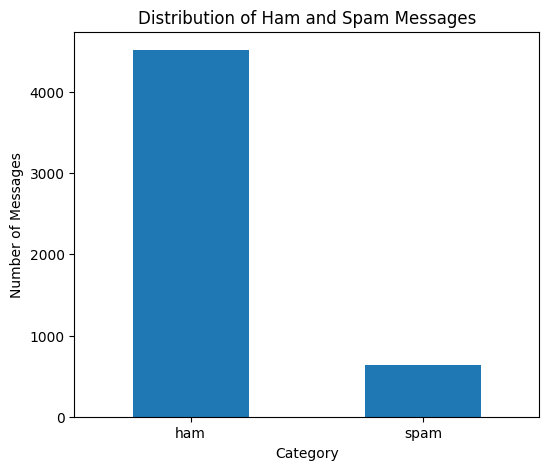

In [17]:
plt.figure(figsize=(6, 5))
df["Category"].value_counts().plot(kind="bar")

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Category")
plt.ylabel("Number of Messages")
plt.xticks(rotation=0)
plt.show()


### Observation

The dataset contains significantly more **ham** messages than **spam** messages. Therefore, the target variable is **imbalanced**.

This is important when evaluating the final classification model. Accuracy alone may not be sufficient; precision, recall, and F1-score should also be considered.


## 7. Create Text-Based Features

To better understand the SMS messages, create the following features:

- `num_characters`: Number of characters in a message.
- `num_words`: Number of word tokens in a message.
- `num_sentences`: Number of sentence tokens in a message.


In [18]:
df["num_characters"] = df["Message"].apply(len)

df["num_words"] = df["Message"].apply(
    lambda x: len(nltk.word_tokenize(x))
)

df["num_sentences"] = df["Message"].apply(
    lambda x: len(nltk.sent_tokenize(x))
)

df.head()


,Category,Message,num_characters,num_words,num_sentences
0,ham,"Go until jurong point, crazy.. Available only ...",111,24,2
1,ham,Ok lar... Joking wif u oni...,29,8,2
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,ham,U dun say so early hor... U c already then say...,49,13,1
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,15,1


## 8. Statistical Analysis of Text Features

Generate descriptive statistics for message length, word count, and sentence count.


In [19]:
df[["num_characters", "num_words", "num_sentences"]].describe()


,num_characters,num_words,num_sentences
count,5157.000000,5157.000000,5157.000000
mean,79.228040,18.544890,1.969750
std,58.451149,13.401415,1.455526
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,118.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


### Ham Message Statistics


In [20]:
df[df["Category"] == "ham"][
    ["num_characters", "num_words", "num_sentences"]
].describe()


,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.951063,17.250664,1.827724
std,56.730031,13.581714,1.394338
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


### Spam Message Statistics


In [21]:
df[df["Category"] == "spam"][
    ["num_characters", "num_words", "num_sentences"]
].describe()


,num_characters,num_words,num_sentences
count,641.000000,641.000000,641.000000
mean,137.541342,27.663027,2.970359
std,30.516111,7.104050,1.485575
min,7.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


### Observation

Comparing the descriptive statistics helps determine whether spam and ham messages differ in length, word count, and sentence count.

Spam messages often contain promotional information, contact instructions, or offer details, which may cause them to be longer than regular messages.


## 9. Message Length Distribution: Spam vs Ham

Compare the number of characters in ham and spam messages using overlapping histograms.


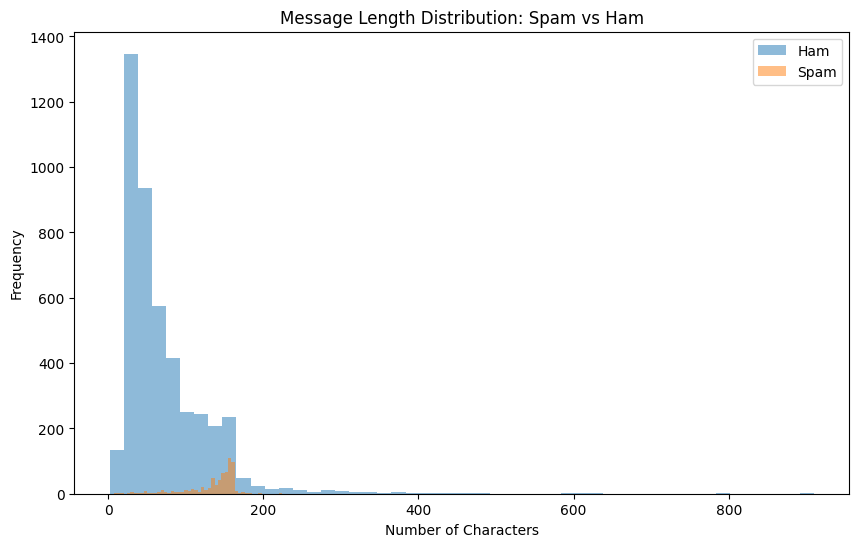

In [22]:
plt.figure(figsize=(10, 6))

plt.hist(
    df[df["Category"] == "ham"]["num_characters"],
    bins=50,
    alpha=0.5,
    label="Ham"
)

plt.hist(
    df[df["Category"] == "spam"]["num_characters"],
    bins=50,
    alpha=0.5,
    label="Spam"
)

plt.title("Message Length Distribution: Spam vs Ham")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.legend()
plt.show()


### Observation

The histogram allows us to compare the distribution of message lengths. Differences in these distributions suggest that message length may contain useful information for spam classification.


## 10. Word Count Distribution: Spam vs Ham


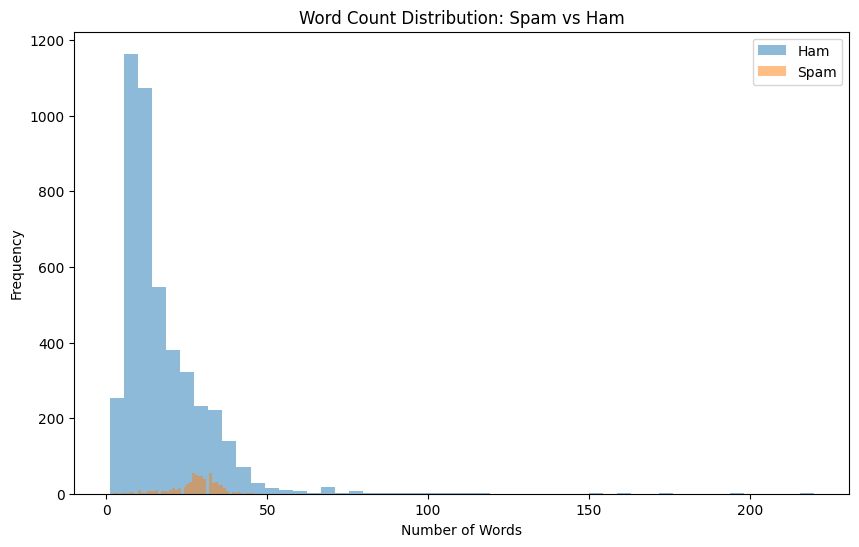

In [23]:
plt.figure(figsize=(10, 6))

plt.hist(
    df[df["Category"] == "ham"]["num_words"],
    bins=50,
    alpha=0.5,
    label="Ham"
)

plt.hist(
    df[df["Category"] == "spam"]["num_words"],
    bins=50,
    alpha=0.5,
    label="Spam"
)

plt.title("Word Count Distribution: Spam vs Ham")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.legend()
plt.show()


### Observation

This visualization compares the number of tokens in spam and ham messages. A difference in word-count patterns may help distinguish the two classes.


## 11. Correlation Between Numerical Features

Analyze the relationship between character count, word count, and sentence count.


In [24]:
correlation_matrix = df[
    ["num_characters", "num_words", "num_sentences"]
].corr()

correlation_matrix


,num_characters,num_words,num_sentences
num_characters,1.000000,0.966006,0.622302
num_words,0.966006,1.000000,0.679503
num_sentences,0.622302,0.679503,1.000000


In [ ]:
plt.figure(figsize=(7, 5))
plt.imshow(correlation_matrix, interpolation="nearest")
plt.title("Correlation Matrix of Text Features")
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.colorbar()

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


### Observation

Character count and word count are expected to be strongly correlated because messages with more words generally contain more characters.

Highly correlated features may provide similar information. This should be considered during feature selection.


## 12. Text Preprocessing

Before analyzing common words, clean the message text.

The preprocessing steps are:

1. Convert text to lowercase.
2. Tokenize the text.
3. Remove non-alphanumeric tokens.
4. Remove English stop words.
5. Apply stemming.


In [25]:
ps = PorterStemmer()
english_stopwords = set(stopwords.words("english"))

def transform_text(text):
    text = text.lower()
    words = nltk.word_tokenize(text)

    cleaned_words = []

    for word in words:
        if word.isalnum() and word not in english_stopwords:
            cleaned_words.append(ps.stem(word))

    return " ".join(cleaned_words)


### Test the Preprocessing Function


In [26]:
transform_text(
    "Congratulations! You have WON a FREE prize. Call now!"
)


'congratul free prize call'

### Apply Text Preprocessing


In [27]:
df["transformed_text"] = df["Message"].apply(transform_text)
df[["Message", "transformed_text"]].head()


,Message,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


## 13. Most Common Words in Spam Messages

Create a corpus containing all cleaned words from spam messages and find the 30 most frequently occurring words.


In [28]:
spam_corpus = []

for message in df[df["Category"] == "spam"]["transformed_text"]:
    spam_corpus.extend(message.split())

len(spam_corpus)


9774

In [29]:
spam_common_words = pd.DataFrame(
    Counter(spam_corpus).most_common(30),
    columns=["Word", "Count"]
)

spam_common_words


,Word,Count
0,call,311
1,free,186
2,2,154
3,txt,139
4,text,122
5,ur,119
6,u,114
7,mobil,110
8,stop,108
9,repli,103


### Visualize the Most Common Spam Words


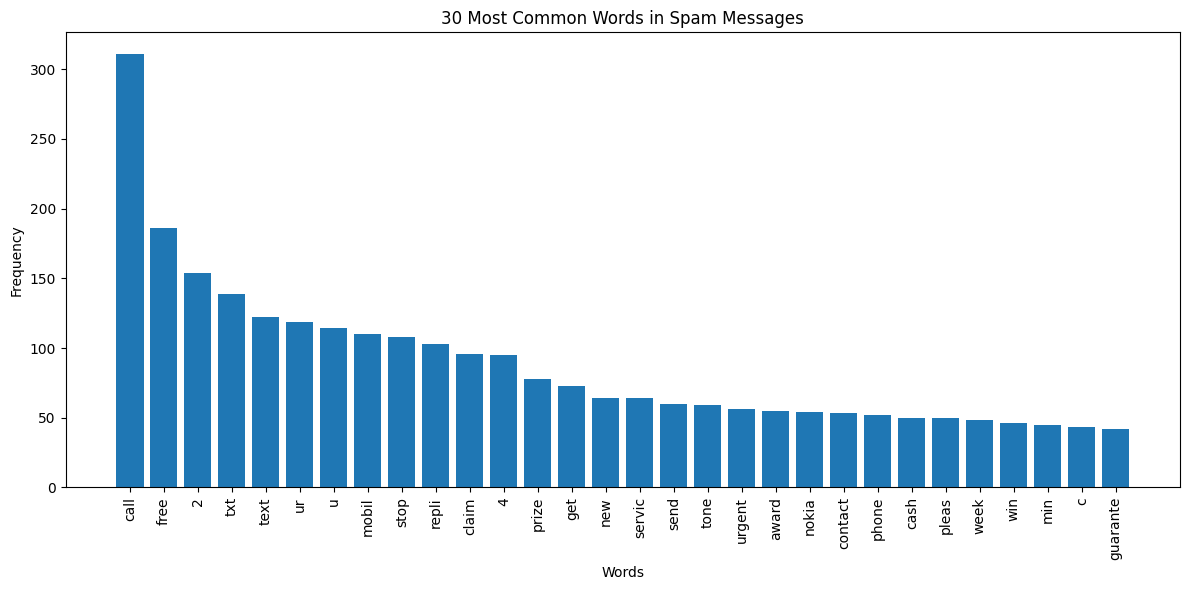

In [30]:
plt.figure(figsize=(12, 6))

plt.bar(
    spam_common_words["Word"],
    spam_common_words["Count"]
)

plt.title("30 Most Common Words in Spam Messages")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Observation

Frequently occurring spam words can reveal promotional, reward-based, or action-oriented language patterns.

Words related to offers, prizes, calling, claiming, and free services may occur frequently in spam messages.


## 14. Most Common Words in Ham Messages

Repeat the same analysis for normal, non-spam messages.


In [31]:
ham_corpus = []

for message in df[df["Category"] == "ham"]["transformed_text"]:
    ham_corpus.extend(message.split())

len(ham_corpus)


35879

In [32]:
ham_common_words = pd.DataFrame(
    Counter(ham_corpus).most_common(30),
    columns=["Word", "Count"]
)

ham_common_words


,Word,Count
0,u,897
1,go,407
2,get,351
3,2,288
4,gt,288
5,lt,287
6,come,278
7,got,239
8,know,237
9,like,236


### Visualize the Most Common Ham Words


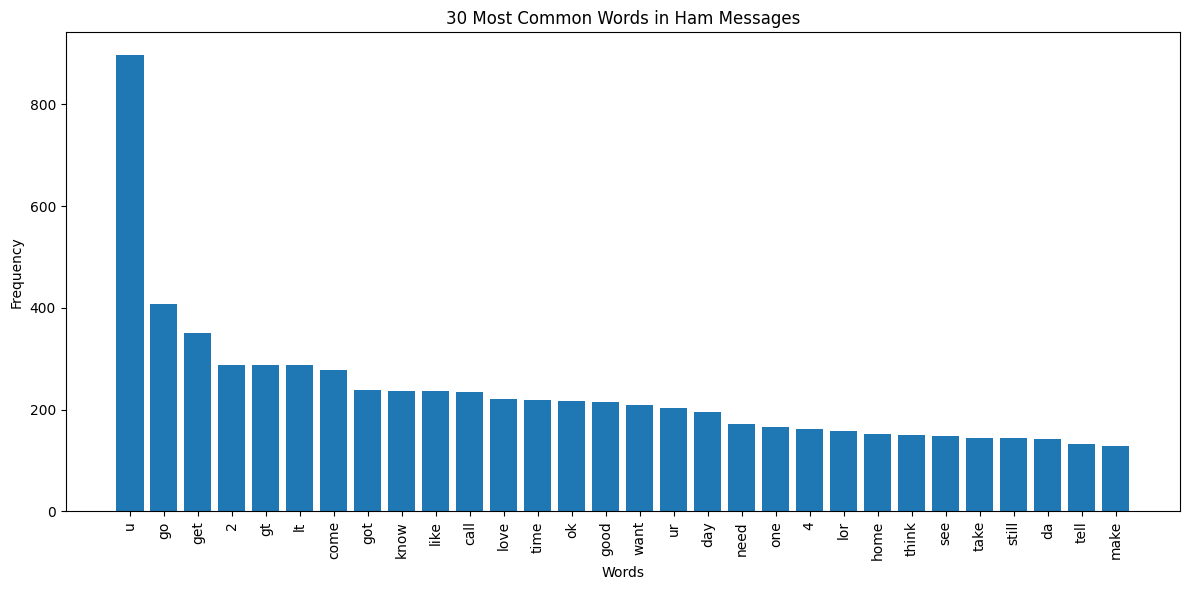

In [33]:
plt.figure(figsize=(12, 6))

plt.bar(
    ham_common_words["Word"],
    ham_common_words["Count"]
)

plt.title("30 Most Common Words in Ham Messages")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


### Observation

Ham messages generally contain conversational and informal language. Comparing common ham words with spam words highlights differences in vocabulary and message intent.


## 15. EDA Conclusions

Based on the exploratory data analysis:

1. The dataset contains SMS messages classified as **ham** or **spam**.
2. The original dataset contains **5,572 records and 2 columns**.
3. There are no missing values in the main columns.
4. Duplicate records should be removed before model training.
5. The target variable is **imbalanced**, with substantially more ham messages than spam messages.
6. Message length, word count, and sentence count provide useful information about SMS structure.
7. Spam and ham messages show different text-length and word-count patterns.
8. Character count and word count are strongly related.
9. Text preprocessing removes unnecessary words and symbols and reduces words to stemmed forms.
10. Spam messages contain distinctive frequently occurring words that may be useful for classification.
11. Ham messages contain more conversational vocabulary.


